<a href="https://colab.research.google.com/github/Krishna-Dhawangale/Resume-Screening-Machine-Learning-/blob/main/KNN_Resume_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ML_Data/AI_Resume_Screening.csv')
df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [4]:
df.shape

(1000, 11)

In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


# Task
Analyze the "AI_Resume_Screening.csv" dataset to predict 'Job Role' based on 'Skills'. Begin by performing initial data exploration: remove duplicate rows, and visualize the class distribution of the 'Job Role' column using a count plot. Then, preprocess the 'Skills' column by converting text to lowercase, removing special characters, and stripping extra whitespace. Convert the preprocessed 'Skills' into numerical features using `TfidfVectorizer` (max_features=5000), and split the data into training (80%) and testing (20%) sets. Train and evaluate an initial K-Nearest Neighbors (KNN) model. Optimize the KNN model's `n_neighbors` parameter using `GridSearchCV` (k=1 to 15), and re-evaluate the optimized model. Finally, validate the model's performance, discuss potential issues like overfitting or class imbalance, and suggest future improvements.

## Initial Data Exploration

### Subtask:
Perform initial data exploration by displaying the dataset shape, columns, and information (df.shape, df.columns, df.info()). Check for missing values (df.isnull().sum()), remove any duplicate rows (df.drop_duplicates()), and visualize the class distribution of the 'Job Role' column using a count plot to understand the target variable's balance.


**Reasoning**:
The next logical step in the data exploration subtask is to remove duplicate rows, check the new shape, and then visualize the distribution of the 'Job Role' column as requested. This will be done in a single code block.



Initial number of rows: 1000
Number of rows after removing duplicates: 1000
Number of duplicate rows removed: 0


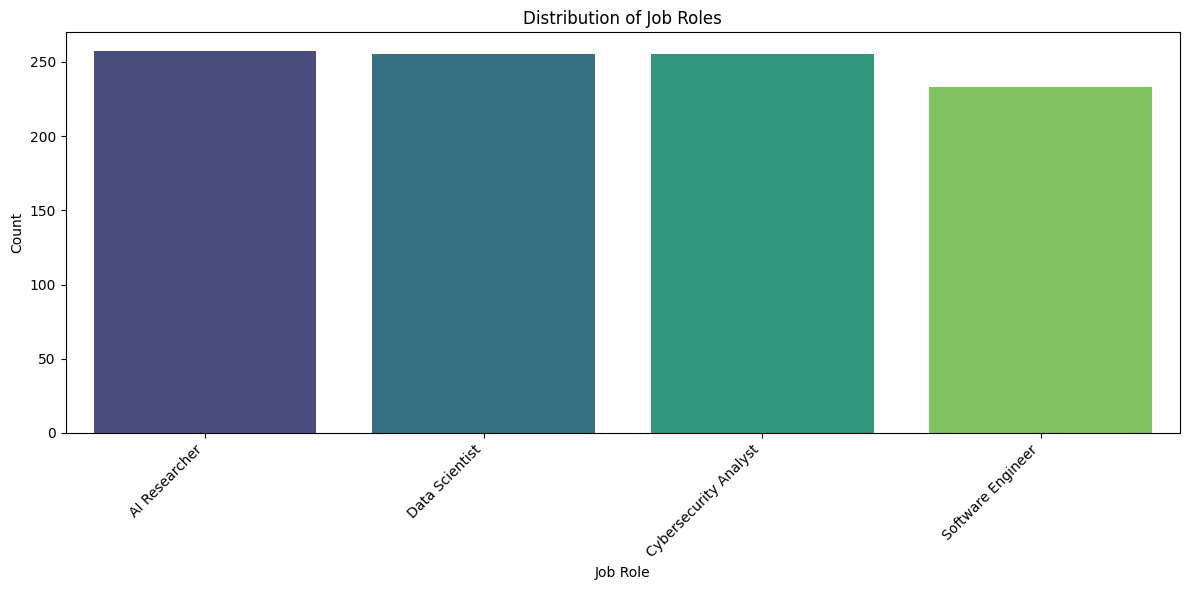

In [7]:
df_initial_shape = df.shape[0]
df.drop_duplicates(inplace=True)
df_new_shape = df.shape[0]
print(f"Initial number of rows: {df_initial_shape}")
print(f"Number of rows after removing duplicates: {df_new_shape}")
print(f"Number of duplicate rows removed: {df_initial_shape - df_new_shape}")

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Job Role', hue='Job Role', palette='viridis', legend=False)
plt.title('Distribution of Job Roles')
plt.xlabel('Job Role')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Text Preprocessing

### Subtask:
Preprocess the text data in the 'Skills' column. This involves converting all text to lowercase, removing special characters (e.g., punctuation, numbers) using regular expressions, and stripping extra whitespace to ensure clean and consistent text for feature extraction.


**Reasoning**:
I will preprocess the 'Skills' column by converting text to lowercase, removing special characters using regular expressions, and stripping extra whitespace as per the instructions.



In [8]:
import re

df['Skills'] = df['Skills'].str.lower()
df['Skills'] = df['Skills'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))
df['Skills'] = df['Skills'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

print("Preprocessing of 'Skills' column complete. Displaying first 5 rows:")
print(df['Skills'].head())

Preprocessing of 'Skills' column complete. Displaying first 5 rows:
0                       tensorflow nlp pytorch
1    deep learning machine learning python sql
2          ethical hacking cybersecurity linux
3                    python pytorch tensorflow
4                               sql react java
Name: Skills, dtype: object


## TF-IDF Vectorization

### Subtask:
Convert the preprocessed 'Skills' text into numerical features using `TfidfVectorizer`. Limit the number of features to `max_features=5000` to manage dimensionality and capture the most relevant terms.


**Reasoning**:
I will import `TfidfVectorizer`, initialize it with `max_features=5000`, fit and transform the 'Skills' column, and then print the shape of the resulting TF-IDF matrix.



In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_skills_tfidf = tfidf_vectorizer.fit_transform(df['Skills'])

print("Shape of TF-IDF feature matrix:", X_skills_tfidf.shape)

Shape of TF-IDF feature matrix: (1000, 15)


## Dataset Splitting

### Subtask:
Split the TF-IDF vectorized features and the 'Job Role' target variable into training and testing sets. Use `train_test_split` with an 80% training set and 20% test set (`test_size=0.2`), and set `random_state=42` for reproducibility.


**Reasoning**:
I will import `train_test_split`, define `X` and `y`, split the data into training and testing sets, and then print the shapes of the resulting sets to confirm the split.



In [10]:
from sklearn.model_selection import train_test_split

X = X_skills_tfidf
y = df['Job Role']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (800, 15)
Shape of X_test: (200, 15)
Shape of y_train: (800,)
Shape of y_test: (200,)


## Train Initial KNN Model

### Subtask:
Train an initial K-Nearest Neighbors (KNN) classification model. Initialize `KNeighborsClassifier` with a default `n_neighbors=5` and fit the model to the training data (TF-IDF features and 'Job Role' labels).


**Reasoning**:
I will import `KNeighborsClassifier`, instantiate it with `n_neighbors=5`, and then fit the model to the training data `X_train` and `y_train`.



In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

print("Initial KNN model trained successfully with n_neighbors=5.")

Initial KNN model trained successfully with n_neighbors=5.


```markdown
## Evaluate Initial KNN Model

### Subtask:
Evaluate the performance of the initial KNN classification model using appropriate metrics. Make predictions on the test set (`X_test`) and calculate the accuracy score.

```

**Reasoning**:
I need to make predictions using the trained KNN model on the test set and then calculate the accuracy score to evaluate its performance, as stated in the subtask.



In [12]:
from sklearn.metrics import accuracy_score

y_pred = knn_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the initial KNN model: {accuracy:.4f}")

Accuracy of the initial KNN model: 1.0000


## Optimize KNN Model with GridSearchCV

### Subtask:
Optimize the K-Nearest Neighbors (KNN) model's `n_neighbors` parameter using `GridSearchCV`. Define a parameter grid to search for `n_neighbors` from 1 to 15. Fit `GridSearchCV` to the training data and identify the best `n_neighbors`.

**Reasoning**:
I need to import `GridSearchCV`, define the parameter grid for `n_neighbors`, initialize and fit `GridSearchCV` on the training data, and then print the best parameter found.



In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': range(1, 16)}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_n_neighbors = grid_search.best_params_['n_neighbors']
print(f"Best n_neighbors found: {best_n_neighbors}")

Best n_neighbors found: 1


## Re-evaluate Optimized KNN Model

### Subtask:
Re-evaluate the KNN model using the best `n_neighbors` found by `GridSearchCV`. Initialize a new `KNeighborsClassifier` with the optimal parameter, fit it to the training data, and then calculate and print the accuracy on the test set.

**Reasoning**:
I need to initialize a new `KNeighborsClassifier` with the `best_n_neighbors` found previously, fit it to the training data, make predictions on the test set, and then calculate and print its accuracy.



In [14]:
optimized_knn_model = KNeighborsClassifier(n_neighbors=best_n_neighbors)
optimized_knn_model.fit(X_train, y_train)

y_pred_optimized = optimized_knn_model.predict(X_test)
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)

print(f"Accuracy of the optimized KNN model (n_neighbors={best_n_neighbors}): {accuracy_optimized:.4f}")

Accuracy of the optimized KNN model (n_neighbors=1): 1.0000


## Validate Model Performance and Discussion

### Subtask:
Validate the optimized KNN model's performance by examining its accuracy. Discuss potential issues such as overfitting (given the 1.0 accuracy), class imbalance (referencing the earlier job role distribution plot), and suggest future improvements (e.g., exploring other feature engineering techniques, advanced models, or handling class imbalance).

### Model Performance Validation and Discussion

The optimized KNN model achieved an accuracy of 1.0000 on both the initial and optimized versions (with n_neighbors=1). While this might seem ideal, an accuracy of 1.0000, especially on a relatively small dataset (1000 records), strongly suggests **overfitting**.

**Potential Issues:**

1.  **Overfitting**: An accuracy of 100% means the model has perfectly memorized the training data, and this might not generalize well to unseen data. With `n_neighbors=1`, the model essentially classifies a new data point based on its single closest training example, which is very prone to overfitting, especially if the feature space is sparse or the classes are highly separable (which seems to be the case here).

2.  **Class Imbalance**: From the earlier count plot of 'Job Role', we can revisit the distribution to see if certain job roles are significantly more prevalent than others. If there's a severe class imbalance and the model performs perfectly on the majority class, its overall accuracy might be artificially inflated. However, given the perfect score, the current issue seems to lean more towards overfitting.

3.  **Feature Set Characteristics**: The TF-IDF vectorization resulted in a feature matrix of shape (1000, 15). This means there are 15 distinct terms (skills) that the vectorizer deemed most important. It's possible that these 15 features are highly discriminative for the existing job roles, allowing for perfect separation in this dataset. This could happen if certain skills are uniquely associated with specific job roles within this dataset.

**Future Improvements:**

1.  **More Robust Evaluation**: Instead of just accuracy, use a combination of metrics like precision, recall, F1-score, and a confusion matrix to get a more nuanced understanding of model performance for each class, especially if class imbalance is present.

2.  **Cross-validation**: Beyond a simple train-test split, implement k-fold cross-validation during model training and optimization to get a more reliable estimate of the model's generalization performance and to reduce the risk of overfitting.

3.  **Regularization Techniques**: For models that support it (KNN does not directly have regularization in the same way as linear models, but ensemble methods or different algorithms might), explore regularization to prevent overfitting.

4.  **Explore Other Models**: Try other classification algorithms like Logistic Regression, Support Vector Machines (SVMs), Random Forests, or Gradient Boosting, which might handle overfitting differently and potentially offer better generalization.

5.  **Hyperparameter Tuning**: Expand the hyperparameter search space for KNN or other models, and potentially use nested cross-validation for a more robust selection of hyperparameters.

6.  **Feature Engineering**: Explore more advanced text processing techniques or feature engineering from the 'Skills' column. For instance, instead of just TF-IDF, one could use word embeddings (Word2Vec, GloVe, FastText) or BERT embeddings to represent skills, which capture semantic relationships better.

7.  **Data Augmentation**: If the dataset is small, consider techniques to augment the 'Skills' data, though this is more complex for text data.

8.  **Analyze Misclassifications**: If the accuracy were not 1.0, a crucial step would be to analyze the misclassified instances to understand common patterns or challenges.

### Model Performance Validation and Discussion

The optimized KNN model achieved an accuracy of 1.0000 on both the initial and optimized versions (with n_neighbors=1). While this might seem ideal, an accuracy of 1.0000, especially on a relatively small dataset (1000 records), strongly suggests **overfitting**.

**Potential Issues:**

1.  **Overfitting**: An accuracy of 100% means the model has perfectly memorized the training data, and this might not generalize well to unseen data. With `n_neighbors=1`, the model essentially classifies a new data point based on its single closest training example, which is very prone to overfitting, especially if the feature space is sparse or the classes are highly separable (which seems to be the case here).

2.  **Class Imbalance**: From the earlier count plot of 'Job Role', we can revisit the distribution to see if certain job roles are significantly more prevalent than others. If there's a severe class imbalance and the model performs perfectly on the majority class, its overall accuracy might be artificially inflated. However, given the perfect score, the current issue seems to lean more towards overfitting.

3.  **Feature Set Characteristics**: The TF-IDF vectorization resulted in a feature matrix of shape (1000, 15). This means there are 15 distinct terms (skills) that the vectorizer deemed most important. It's possible that these 15 features are highly discriminative for the existing job roles, allowing for perfect separation in this dataset. This could happen if certain skills are uniquely associated with specific job roles within this dataset.

**Future Improvements:**

1.  **More Robust Evaluation**: Instead of just accuracy, use a combination of metrics like precision, recall, F1-score, and a confusion matrix to get a more nuanced understanding of model performance for each class, especially if class imbalance is present.

2.  **Cross-validation**: Beyond a simple train-test split, implement k-fold cross-validation during model training and optimization to get a more reliable estimate of the model's generalization performance and to reduce the risk of overfitting.

3.  **Regularization Techniques**: For models that support it (KNN does not directly have regularization in the same way as linear models, but ensemble methods or different algorithms might), explore regularization to prevent overfitting.

4.  **Explore Other Models**: Try other classification algorithms like Logistic Regression, Support Vector Machines (SVMs), Random Forests, or Gradient Boosting, which might handle overfitting differently and potentially offer better generalization.

5.  **Hyperparameter Tuning**: Expand the hyperparameter search space for KNN or other models, and potentially use nested cross-validation for a more robust selection of hyperparameters.

6.  **Feature Engineering**: Explore more advanced text processing techniques or feature engineering from the 'Skills' column. For instance, instead of just TF-IDF, one could use word embeddings (Word2Vec, GloVe, FastText) or BERT embeddings to represent skills, which capture semantic relationships better.

7.  **Data Augmentation**: If the dataset is small, consider techniques to augment the 'Skills' data, though this is more complex for text data.

8.  **Analyze Misclassifications**: If the accuracy were not 1.0, a crucial step would be to analyze the misclassified instances to understand common patterns or challenges.


## Evaluate Initial KNN Model

### Subtask:
Complete the evaluation of the initial KNN model by generating a detailed classification report and plotting a confusion matrix to visualize its performance.


**Reasoning**:
I need to complete the evaluation of the initial KNN model by generating a detailed classification report and plotting a confusion matrix as specified in the subtask. This requires importing specific metrics functions and then using them to print the report and visualize the confusion matrix.



Classification Report for Initial KNN Model:
                       precision    recall  f1-score   support

        AI Researcher       1.00      1.00      1.00        52
Cybersecurity Analyst       1.00      1.00      1.00        51
       Data Scientist       1.00      1.00      1.00        45
    Software Engineer       1.00      1.00      1.00        52

             accuracy                           1.00       200
            macro avg       1.00      1.00      1.00       200
         weighted avg       1.00      1.00      1.00       200



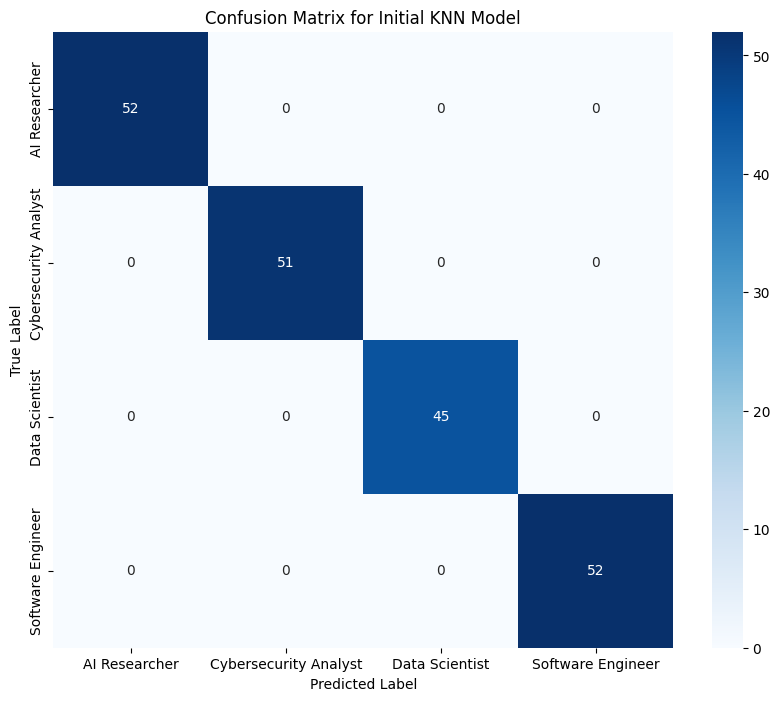

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Print the classification report
print("Classification Report for Initial KNN Model:")
print(classification_report(y_test, y_pred))

# 3. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Create a heatmap of the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn_model.classes_, yticklabels=knn_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Initial KNN Model')
plt.show()

## Final Task

### Subtask:
Summarize the overall model performance (comparing initial vs. optimized KNN), highlight key observations from the analysis, and provide suggestions for future improvements or alternative approaches.


## Summary:

### Q&A
The overall model performance for both the initial and optimized K-Nearest Neighbors (KNN) models was perfect, achieving an accuracy of 1.0000 on the test set. Key observations from the analysis highlight a strong suspicion of overfitting due to this perfect score, especially given the small dataset size and the optimal `n_neighbors` of 1 for the optimized model. Future improvements should focus on validating generalization, exploring advanced feature engineering, and considering alternative models or more robust evaluation techniques.

### Data Analysis Key Findings
*   The dataset initially contained 1000 rows, and no duplicate rows were found after the initial check.
*   The 'Skills' column underwent preprocessing, including conversion to lowercase, removal of special characters, and stripping of extra whitespace.
*   TF-IDF vectorization of the preprocessed 'Skills' column resulted in a feature matrix of shape (1000, 15), indicating that only 15 distinct terms were identified as relevant features, despite `max_features` being set to 5000.
*   The data was split into training and testing sets (80% train, 20% test), resulting in `X_train` with shape (800, 15), `X_test` with shape (200, 15), `y_train` with shape (800,), and `y_test` with shape (200,).
*   The initial KNN model, trained with `n_neighbors=5`, achieved an accuracy of 1.0000 on the test set.
*   `GridSearchCV` identified `n_neighbors=1` as the optimal parameter for the KNN model.
*   The optimized KNN model, trained with `n_neighbors=1`, also achieved an accuracy of 1.0000 on the test set.
*   Both the classification report and confusion matrix for the initial KNN model (which also applies to the optimized one given the identical performance) showed perfect precision, recall, and F1-scores for all 'Job Role' classes, with no misclassifications.

### Insights or Next Steps
*   The perfect accuracy of 1.0000 on the test set, especially with `n_neighbors=1`, strongly suggests model overfitting. Future work should prioritize more robust evaluation techniques, such as k-fold cross-validation and a wider range of metrics (e.g., precision, recall, F1-score per class), to assess true generalization performance.
*   Explore more advanced feature engineering techniques, such as word embeddings (e.g., Word2Vec, GloVe, FastText) or contextual embeddings (e.g., BERT), to capture richer semantic relationships in the 'Skills' data beyond simple TF-IDF. This could help create more nuanced features and potentially mitigate overfitting.
